# 03 — Feature Engineering (LOCAL)
## WavSent-MTL · Tasks 1.19–1.23

**Pipeline steps covered (Steps 4–5 for BOTH datasets):**
- Step 4: Coif3 wavelet denoising on OHLCV (Open, High, Low, Close, Volume independently)
- Step 5: Compute all 15 candidate technical features on DENOISED prices only

**CRITICAL:**
- Features are NEVER computed on raw prices — always on *_d columns
- Both kotekar and kaggle get the same treatment
- Output: `data/processed/{dataset}/featured_data.csv`

**15 candidate features:** Close_d, Open_d, High_d, Low_d, Volume_d,
RSI_14, MACD, BB_width, ROC_5, EMA_9, ATR_14, OBV, STOCH_K, WILLIAMS_R, CCI_20

In [1]:
import sys
import os

project_root = os.path.abspath('..')
if project_root not in sys.path:
    sys.path.insert(0, project_root)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from config.config import CONFIG

print('CONFIG loaded.')
print('Candidate features:', CONFIG['candidate_features'])
print('Wavelet:', CONFIG['wavelet'], '| Level:', CONFIG['wavelet_level'], '| Mode:', CONFIG['wavelet_mode'])

CONFIG loaded.
Candidate features: ['Close_d', 'Open_d', 'High_d', 'Low_d', 'Volume_d', 'RSI_14', 'MACD', 'BB_width', 'ROC_5', 'EMA_9', 'ATR_14', 'OBV', 'STOCH_K', 'WILLIAMS_R', 'CCI_20']
Wavelet: coif3 | Level: 1 | Mode: soft


## Helper: Process One Dataset

In [2]:
from src.data.preprocessor import denoise_ohlcv
from src.data.feature_engineering import compute_all_features


def build_featured_data(merged_csv_path: str, out_csv_path: str, dataset_name: str) -> pd.DataFrame:
    """Apply Coif3 denoising + compute all 15 features for one dataset.

    Args:
        merged_csv_path: Path to merged_data.csv (output of notebooks 01/02).
        out_csv_path:    Destination path for featured_data.csv.
        dataset_name:    'kotekar' or 'kaggle' (for logging).

    Returns:
        DataFrame with all 15 candidate features + date + Close + sentiment cols.
    """
    print(f'\n{"=" * 55}')
    print(f'Processing: {dataset_name}')
    print(f'{"=" * 55}')

    # Load merged data
    df = pd.read_csv(merged_csv_path)
    df['Date'] = pd.to_datetime(df['Date'])
    df = df.sort_values('Date').reset_index(drop=True)
    print(f'Loaded: {df.shape} | {df["Date"].min().date()} -> {df["Date"].max().date()}')

    # Step 4: Coif3 denoising
    df = denoise_ohlcv(df)
    denoised_cols = [f'{c}_d' for c in CONFIG['ohlcv_cols']]
    print(f'Denoised columns added: {denoised_cols}')

    # Step 5: Compute all 15 features on denoised prices
    df = compute_all_features(df)
    print(f'Features computed. Shape: {df.shape}')

    # Keep date + Close (for targets) + all 15 candidates + sentiment
    sentiment_cols = [c for c in ['polarity_mean', 'polarity_max'] if c in df.columns]
    keep_cols = ['Date'] + CONFIG['candidate_features'] + ['Close'] + sentiment_cols
    df_out = df[keep_cols].copy()

    # Drop warmup rows (first 26 rows for MACD: EMA-26 warmup)
    warmup = CONFIG['warmup_days']
    n_before = len(df_out)
    df_out = df_out.dropna(subset=CONFIG['candidate_features']).reset_index(drop=True)
    n_after = len(df_out)
    print(f'Dropped {n_before - n_after} warmup/NaN rows (warmup_days={warmup})')

    # Save
    os.makedirs(os.path.dirname(out_csv_path), exist_ok=True)
    df_out.to_csv(out_csv_path, index=False)
    print(f'Saved: {out_csv_path}')
    print(f'Final shape: {df_out.shape}')

    return df_out

## Task 1.19-1.20 — Process Kotekar Dataset

In [3]:
kotekar_merged  = os.path.join(project_root, CONFIG['kotekar_processed_dir'], 'merged_data.csv')
kotekar_out     = os.path.join(project_root, CONFIG['kotekar_processed_dir'], 'featured_data.csv')

df_kotekar = build_featured_data(kotekar_merged, kotekar_out, 'kotekar')
df_kotekar.head(3)


Processing: kotekar
Loaded: (1092, 7) | 2020-01-01 -> 2024-05-31
Denoised columns added: ['Open_d', 'High_d', 'Low_d', 'Close_d', 'Volume_d']
Features computed. Shape: (1092, 22)
Dropped 25 warmup/NaN rows (warmup_days=26)
Saved: d:/WavSent-MTL/data/processed/kotekar/featured_data.csv
Final shape: (1067, 18)


,Date,Close_d,Open_d,High_d,Low_d,Volume_d,RSI_14,MACD,BB_width,ROC_5,EMA_9,ATR_14,OBV,STOCH_K,WILLIAMS_R,CCI_20,Close,polarity_mean
0,2020-01-28,12128.942120,12179.583646,12211.800802,12100.981238,448585.144027,55.059502,-9.004343,0.034965,-0.014603,12181.789496,104.789974,2.118666e+06,11.673879,-88.326121,-51.239948,12055.7998,0.0
1,2020-01-29,12117.376391,12144.364772,12180.980704,12083.482078,497186.119867,43.574256,-14.204085,0.035547,-0.308704,12168.906875,101.801766,1.621480e+06,9.923573,-90.076427,-62.933336,12129.5000,0.0
2,2020-01-30,12000.663046,12091.507541,12103.893674,11987.173224,603938.879238,27.939158,-27.426553,0.038466,-1.671894,12135.258109,104.487641,1.017541e+06,3.080836,-96.919164,-123.511254,12035.7998,0.0


## Task 1.21 — Spot Check Kotekar Features

In [4]:
# Spot check 1: RSI range 0-100
rsi_valid = df_kotekar['RSI_14'].between(0, 100)
print(f'RSI in [0,100]: {rsi_valid.all()}  ({rsi_valid.sum()}/{len(rsi_valid)} rows)')
assert rsi_valid.all(), 'RSI out of [0,100] range'

# Spot check 2: MACD sign matches Close_d direction
close_diff = df_kotekar['Close_d'].diff()
macd_pos = df_kotekar['MACD'] > 0
close_up  = close_diff > 0
agreement = (macd_pos == close_up).mean()
print(f'MACD/price direction agreement: {agreement:.1%} (expected > 50%)')

# Spot check 3: ATR always non-negative
atr_ok = (df_kotekar['ATR_14'] >= 0).all()
print(f'ATR >= 0: {atr_ok}')
assert atr_ok, 'ATR has negative values'

# Spot check 4: No NaN in any candidate feature
nan_total = df_kotekar[CONFIG['candidate_features']].isnull().sum().sum()
print(f'NaN in candidate features: {nan_total}')
assert nan_total == 0, f'Found {nan_total} NaN values in features'

print()
print('All spot checks PASSED  OK')

RSI in [0,100]: True  (1067/1067 rows)
MACD/price direction agreement: 55.3% (expected > 50%)
ATR >= 0: True
NaN in candidate features: 0

All spot checks PASSED  OK


## Wavelet Denoising Visualization (Kotekar)

Saved: results/figures/kotekar/wavelet_denoising.png


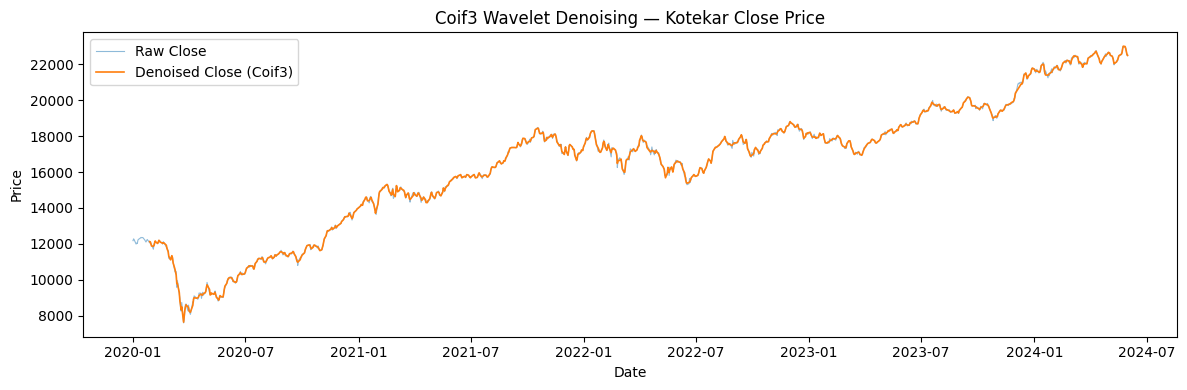

In [6]:
# Reload merged to get raw prices for comparison
df_raw = pd.read_csv(kotekar_merged)
df_raw['Date'] = pd.to_datetime(df_raw['Date'])

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(df_raw['Date'], df_raw['Close'], alpha=0.5, label='Raw Close', linewidth=0.8)
ax.plot(df_kotekar['Date'], df_kotekar['Close_d'][:len(df_raw)], label='Denoised Close (Coif3)', linewidth=1.2)
ax.set_title('Coif3 Wavelet Denoising — Kotekar Close Price')
ax.set_xlabel('Date')
ax.set_ylabel('Price')
ax.legend()
plt.tight_layout()

fig_dir = os.path.join(project_root, CONFIG['figures_dir'], 'kotekar')
os.makedirs(fig_dir, exist_ok=True)
fig.savefig(os.path.join(fig_dir, 'wavelet_denoising.png'), dpi=150)
print('Saved: results/figures/kotekar/wavelet_denoising.png')
plt.show()

## Task 1.19-1.20 — Process Kaggle Dataset

In [7]:
kaggle_merged = os.path.join(project_root, CONFIG['kaggle_processed_dir'], 'merged_data.csv')
kaggle_out    = os.path.join(project_root, CONFIG['kaggle_processed_dir'], 'featured_data.csv')

df_kaggle = build_featured_data(kaggle_merged, kaggle_out, 'kaggle')
df_kaggle.head(3)


Processing: kaggle
Loaded: (1826, 8) | 2017-01-02 -> 2024-05-31
Denoised columns added: ['Open_d', 'High_d', 'Low_d', 'Close_d', 'Volume_d']
Features computed. Shape: (1826, 23)
Dropped 32 warmup/NaN rows (warmup_days=26)
Saved: d:/WavSent-MTL/data/processed/kaggle/featured_data.csv
Final shape: (1794, 19)


,Date,Close_d,Open_d,High_d,Low_d,Volume_d,RSI_14,MACD,BB_width,ROC_5,EMA_9,ATR_14,OBV,STOCH_K,WILLIAMS_R,CCI_20,Close,polarity_mean,polarity_max
0,2017-01-30,8629.582188,8624.477531,8672.087323,8592.507413,376750.285956,80.372697,96.769389,0.065419,3.179586,8507.551366,74.744164,1.345989e+06,87.898561,-12.101439,165.520053,8632.750000,0.0,0.0
1,2017-01-31,8595.883855,8599.864623,8645.193830,8541.178389,453489.203614,75.153817,99.273300,0.065280,2.265248,8525.217864,79.671523,8.924998e+05,76.443782,-23.556218,131.642015,8561.299805,0.0,0.0
2,2017-02-01,8662.414085,8632.904310,8692.721648,8583.247247,371004.537354,75.134017,105.410990,0.066696,2.150052,8552.657108,82.001593,1.263504e+06,91.312478,-8.687522,146.975648,8716.400391,0.0,0.0


## Task 1.21 — Spot Check Kaggle Features

In [8]:
# Same checks as kotekar
rsi_valid_kg = df_kaggle['RSI_14'].between(0, 100)
assert rsi_valid_kg.all(), 'Kaggle RSI out of range'
print(f'Kaggle RSI in [0,100]: {rsi_valid_kg.all()}  OK')

atr_ok_kg = (df_kaggle['ATR_14'] >= 0).all()
assert atr_ok_kg, 'Kaggle ATR has negative values'
print(f'Kaggle ATR >= 0: {atr_ok_kg}  OK')

nan_kg = df_kaggle[CONFIG['candidate_features']].isnull().sum().sum()
assert nan_kg == 0, f'Kaggle: {nan_kg} NaN in features'
print(f'Kaggle NaN in features: {nan_kg}  OK')

# Verify polarity_max column exists in kaggle (not in kotekar)
assert 'polarity_max' in df_kaggle.columns, 'polarity_max missing from kaggle'
assert 'polarity_max' not in df_kotekar.columns, 'polarity_max should not be in kotekar'
print(f'polarity_max in kaggle only: OK')

print()
print('All Kaggle spot checks PASSED  OK')

Kaggle RSI in [0,100]: True  OK
Kaggle ATR >= 0: True  OK
Kaggle NaN in features: 0  OK
polarity_max in kaggle only: OK

All Kaggle spot checks PASSED  OK


## Summary

In [9]:
print('=' * 55)
print('Notebook 03 -- Feature Engineering: COMPLETE')
print('=' * 55)
print(f'Kotekar featured_data: {df_kotekar.shape}')
print(f'  Date range: {df_kotekar["Date"].min().date()} -> {df_kotekar["Date"].max().date()}')
print(f'  Columns:    {df_kotekar.columns.tolist()}')
print()
print(f'Kaggle featured_data:  {df_kaggle.shape}')
print(f'  Date range: {df_kaggle["Date"].min().date()} -> {df_kaggle["Date"].max().date()}')
print(f'  Columns:    {df_kaggle.columns.tolist()}')
print()
print('Next: run 04_feature_selection.ipynb')

Notebook 03 -- Feature Engineering: COMPLETE
Kotekar featured_data: (1067, 18)
  Date range: 2020-01-28 -> 2024-05-31
  Columns:    ['Date', 'Close_d', 'Open_d', 'High_d', 'Low_d', 'Volume_d', 'RSI_14', 'MACD', 'BB_width', 'ROC_5', 'EMA_9', 'ATR_14', 'OBV', 'STOCH_K', 'WILLIAMS_R', 'CCI_20', 'Close', 'polarity_mean']

Kaggle featured_data:  (1794, 19)
  Date range: 2017-01-30 -> 2024-05-31
  Columns:    ['Date', 'Close_d', 'Open_d', 'High_d', 'Low_d', 'Volume_d', 'RSI_14', 'MACD', 'BB_width', 'ROC_5', 'EMA_9', 'ATR_14', 'OBV', 'STOCH_K', 'WILLIAMS_R', 'CCI_20', 'Close', 'polarity_mean', 'polarity_max']

Next: run 04_feature_selection.ipynb
